# 🧠 Notebook 08 — Segmentation Training Showcase
## FedMedSeg Phase 2: MobileNetV2-UNet Training

---

**This notebook is designed for teacher demonstration.** It provides a clear, visual, and interactive explanation of the segmentation training process.

### What this notebook does:
1. Displays the MobileNetV2-UNet architecture
2. Shows a sample training batch with masks
3. Runs the full Phase A + Phase B training
4. Renders live loss and metric curves
5. Shows prediction samples during training

---

> **Prerequisite:** Run Notebook 07 first to prepare the dataset.

## 📦 Setup & Imports

In [1]:
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from segmentation.model_unet   import MobileNetV2UNet
from segmentation.loss         import DiceBCELoss
from segmentation.metrics      import compute_all_metrics
from segmentation.dataset_rsna import RSNAPneumoniaDataset
import torchvision.transforms as T
from torch.utils.data import DataLoader

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RSNA_DIR     = PROJECT_ROOT / 'data' / 'rsna_pneumonia'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'segmentation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU:    {torch.cuda.get_device_name(0)}')
print(f'Project Root: {PROJECT_ROOT}')

Device: cuda
GPU:    NVIDIA GeForce RTX 4050 Laptop GPU
Project Root: c:\Users\Vivek Singh Chauhan\Desktop\shubham\FedMedSeg


## 🏛️ Part 1 — Architecture Overview

The MobileNetV2-UNet uses the pre-trained MobileNetV2 as the **Encoder** and adds a custom **Decoder** with transposed convolutions and skip connections.

In [2]:
model = MobileNetV2UNet(pretrained=True, freeze_encoder=True).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

print('=' * 55)
print('  MobileNetV2-UNet Parameter Summary')
print('=' * 55)
print(f'  Total parameters:     {total:>12,}')
print(f'  Trainable (Decoder):  {trainable:>12,}  ← Learning happens here')
print(f'  Frozen (Encoder):     {frozen:>12,}  ← Pre-trained MobileNetV2')
print('=' * 55)

# Shape assertion
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'\nInput  shape: {tuple(dummy.shape)}  →  Input X-ray')
print(f'Output shape: {tuple(out.shape)}  →  Pixel probability mask')
print(f'Output range: [{out.min():.3f}, {out.max():.3f}]  (probabilities after Sigmoid)')
print('\n✓ Architecture verified!')

  MobileNetV2-UNet Parameter Summary
  Total parameters:        4,573,601
  Trainable (Decoder):     2,349,729  ← Learning happens here
  Frozen (Encoder):        2,223,872  ← Pre-trained MobileNetV2

Input  shape: (1, 3, 224, 224)  →  Input X-ray
Output shape: (1, 1, 224, 224)  →  Pixel probability mask
Output range: [0.201, 0.846]  (probabilities after Sigmoid)

✓ Architecture verified!


## 🖼️ Part 2 — Visualize a Training Batch

[RSNAPneumoniaDataset] Loaded 4000 patients
  Pneumonia: 2000
  Normal:    2000


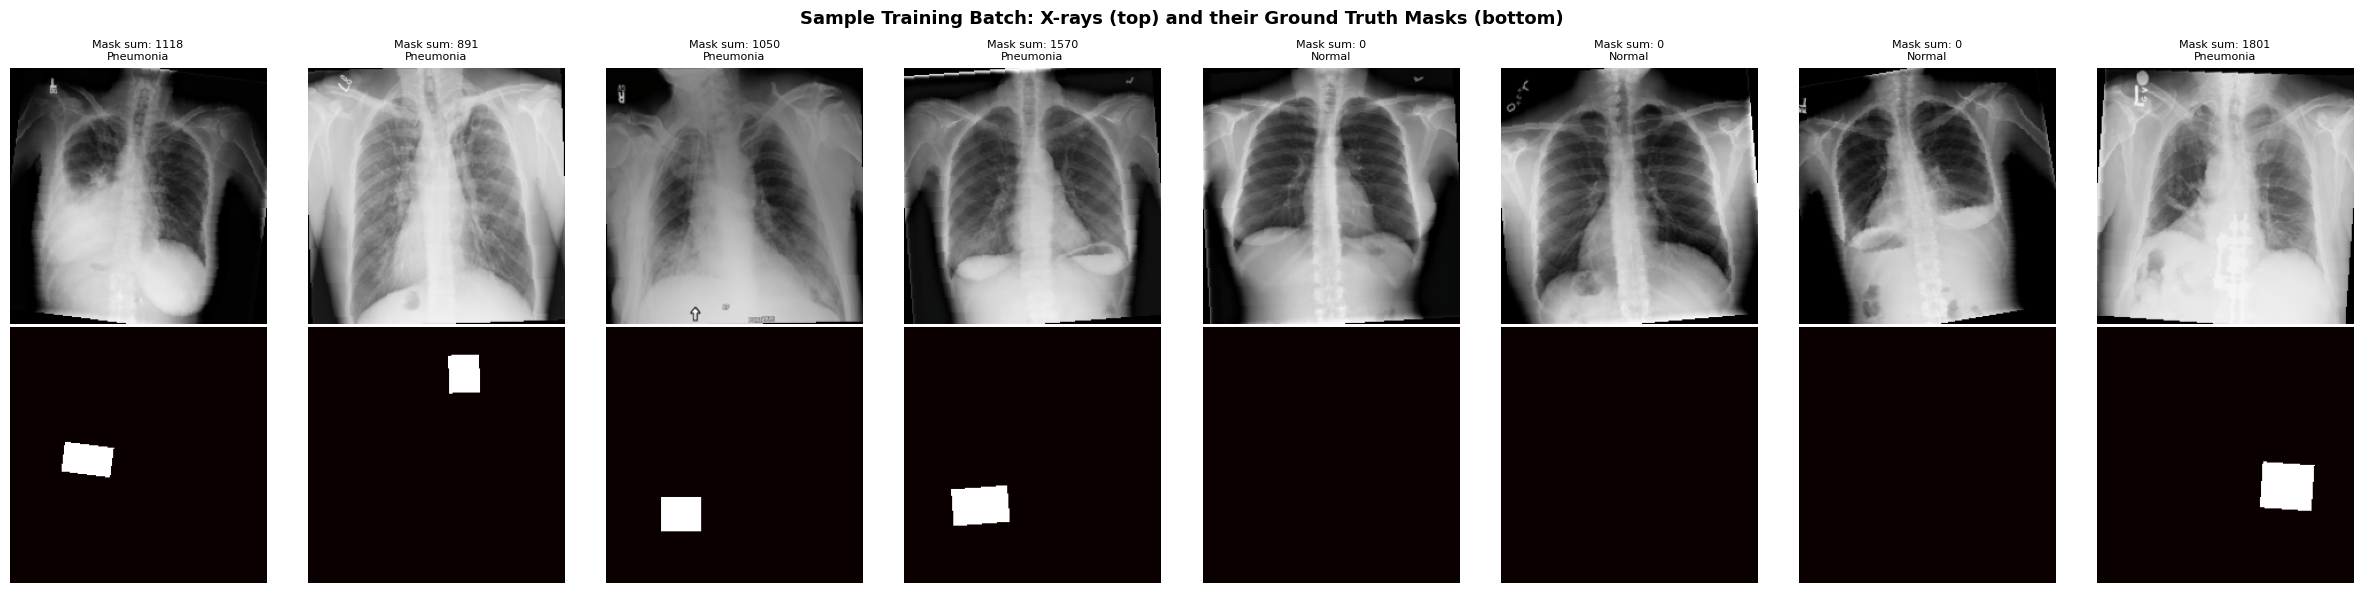

✓ Training batch visualized!


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = RSNAPneumoniaDataset(
    rsna_root     = str(RSNA_DIR),
    subset_csv    = str(RSNA_DIR / 'subset' / 'train_subset.csv'),
    img_transform = transform,
    augment       = True,
)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)

images, masks = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(24, 6))
fig.suptitle('Sample Training Batch: X-rays (top) and their Ground Truth Masks (bottom)',
             fontsize=13, fontweight='bold')

for i in range(8):
    img = images[i].numpy().transpose(1, 2, 0)
    img = (img * np.array(IMAGENET_STD)) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)

    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Mask sum: {masks[i].sum():.0f}\n' +
                          ('Pneumonia' if masks[i].sum() > 0 else 'Normal'), fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(masks[i, 0].numpy(), cmap='hot')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_batch_sample.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ Training batch visualized!')

## 🚂 Part 3 — Run Training

This calls the `train_segmentation.py` script. All logs, checkpoints, and plots will be saved to `results/segmentation/`.

In [4]:
# Run the training script
import subprocess
result = subprocess.run(
    [sys.executable, str(PROJECT_ROOT / 'src' / 'segmentation' / 'train_segmentation.py')],
    cwd=str(PROJECT_ROOT),
    capture_output=False,
    text=True
)
print('Training finished with exit code:', result.returncode)

Training finished with exit code: 0


## 📊 Part 4 — Training Curves (Live results)

In [5]:
log_path = RESULTS_DIR / 'training_logs.csv'
assert log_path.exists(), 'training_logs.csv not found! Run training first.'

df = pd.read_csv(log_path)

print('=== Training Summary ===')
print(f'Total Epochs:    {len(df)}')
print(f'Best Dice Score: {df["val_dice"].max():.4f}  (Epoch {df["val_dice"].idxmax() + 1})')
print(f'Best IoU  Score: {df["val_iou"].max():.4f}  (Epoch {df["val_iou"].idxmax() + 1})')
print(f'Final Pixel Acc: {df["val_pixel_acc"].iloc[-1]:.4f}')
print('\nFull log table:')
df.round(4)

=== Training Summary ===
Total Epochs:    26
Best Dice Score: 0.6239  (Epoch 16)
Best IoU  Score: 0.5626  (Epoch 16)
Final Pixel Acc: 0.9515

Full log table:


,epoch,phase,train_loss,val_loss,train_dice,val_dice,train_iou,val_iou,train_pixel_acc,val_pixel_acc,learning_rate,epoch_time_sec
0,1,A,1.7369,1.6995,0.3823,0.5361,0.3195,0.4703,0.9212,0.9430,0.0001,76.47
1,2,A,1.6949,1.6809,0.5374,0.5455,0.4716,0.4789,0.9431,0.9423,0.0001,77.09
2,3,A,1.6744,1.6639,0.5422,0.5879,0.4760,0.5254,0.9440,0.9494,0.0001,79.22
3,4,A,1.6570,1.6455,0.5616,0.5784,0.4963,0.5150,0.9489,0.9508,0.0001,79.55
4,5,A,1.6427,1.6327,0.5861,0.6006,0.5217,0.5386,0.9511,0.9515,0.0001,79.14
5,6,A,1.6316,1.6234,0.6016,0.6160,0.5382,0.5541,0.9527,0.9514,0.0001,79.40
6,7,A,1.6229,1.6161,0.6105,0.5879,0.5468,0.5224,0.9530,0.9506,0.0001,79.61
7,8,A,1.6159,1.6104,0.6063,0.5987,0.5425,0.5345,0.9539,0.9512,0.0001,79.25
8,9,A,1.6100,1.6057,0.6188,0.5863,0.5551,0.5200,0.9545,0.9480,0.0001,78.75
9,10,B,1.6057,1.6040,0.6310,0.6156,0.5669,0.5524,0.9562,0.9526,0.0000,80.36


=== Loss Curves ===


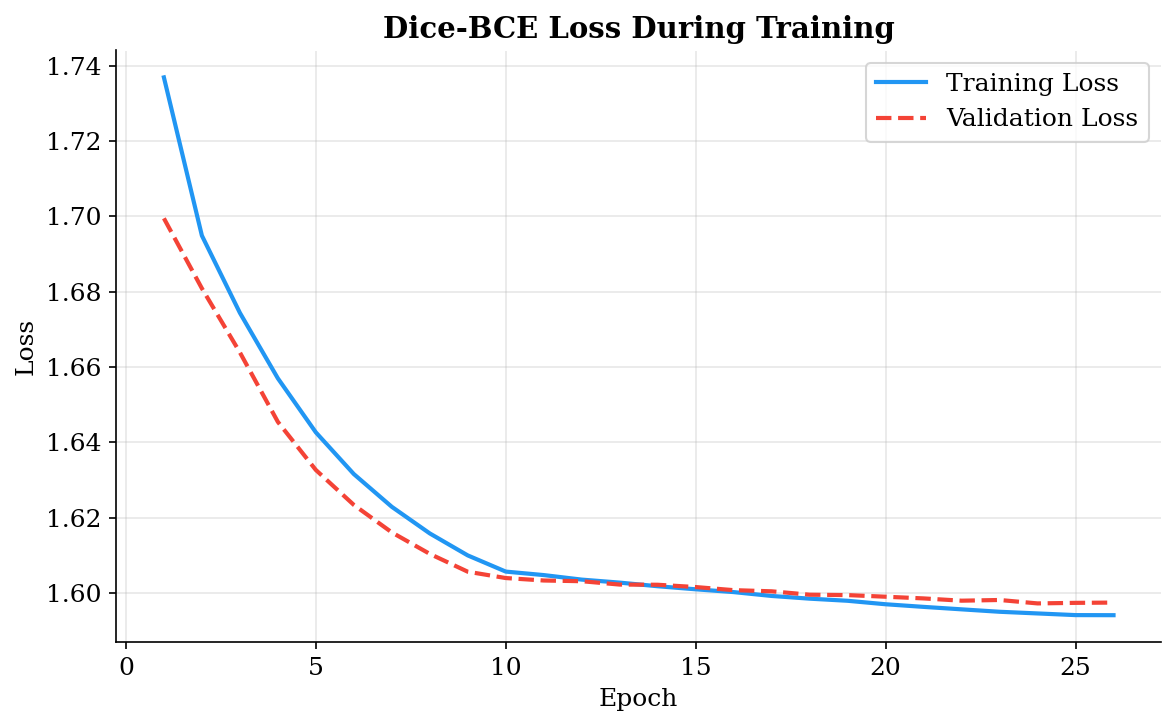


=== Dice & IoU Curves ===


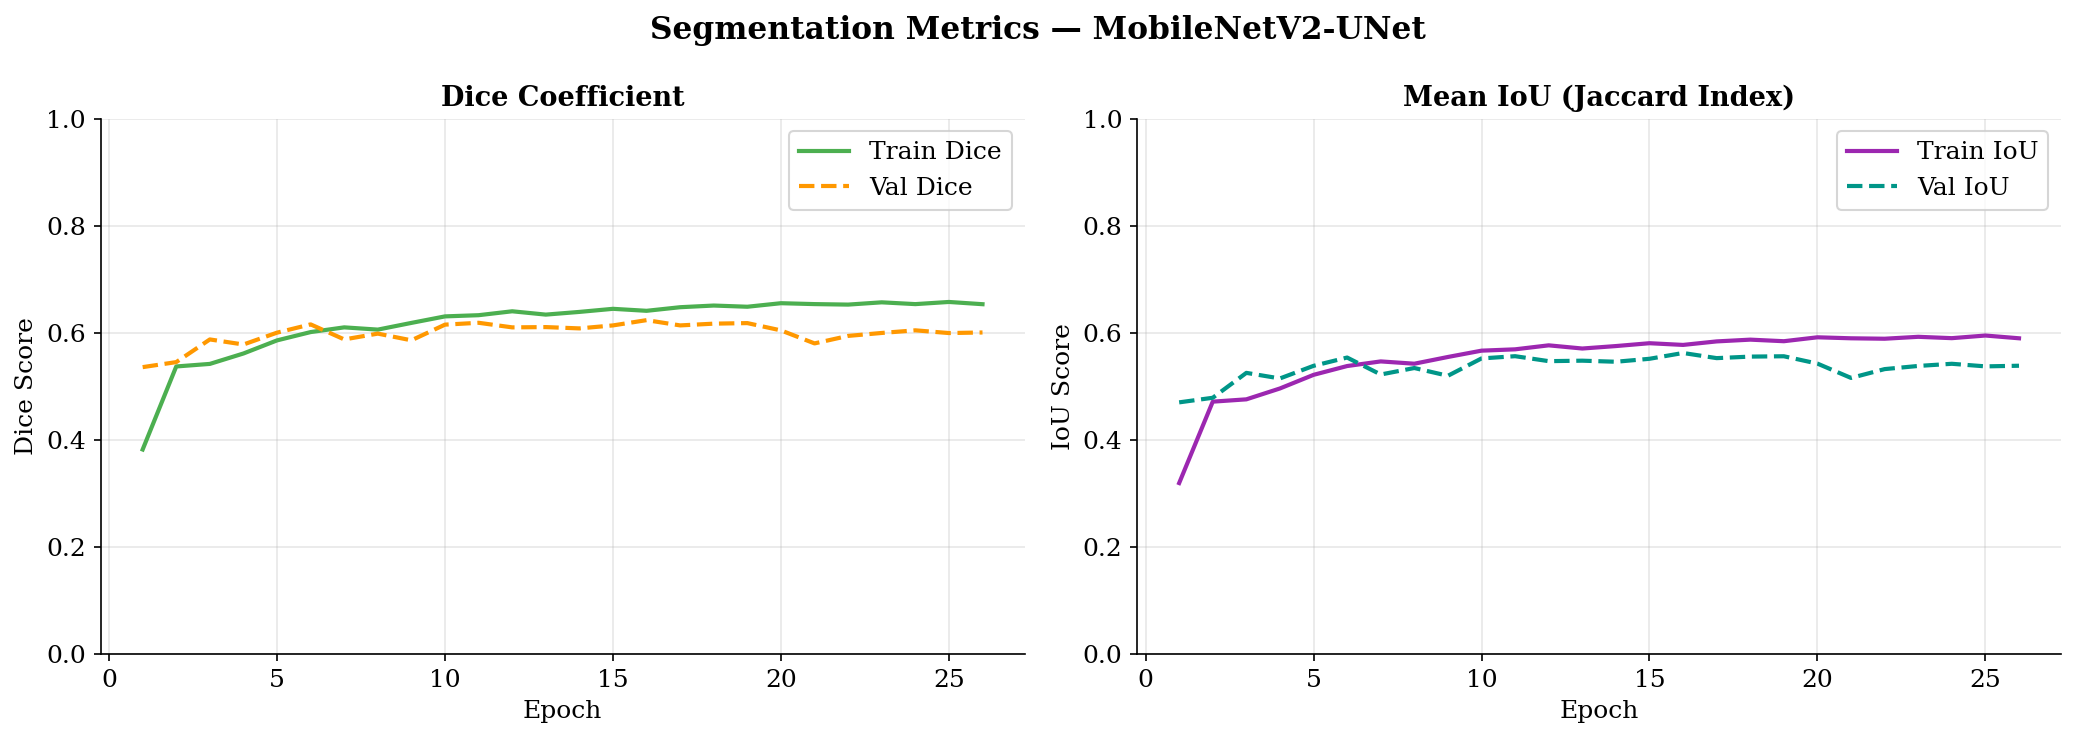

In [6]:
# Display training plots
from IPython.display import Image as IPImage, display

print('=== Loss Curves ===')
display(IPImage(filename=str(RESULTS_DIR / 'loss_curves.png')))

print('\n=== Dice & IoU Curves ===')
display(IPImage(filename=str(RESULTS_DIR / 'dice_iou_curves.png')))

## 🔬 Part 5 — Mid-Training Prediction Preview

Showing 4 prediction samples:
Columns: [Original X-ray | Ground Truth Mask | Model Prediction | Overlay]

--- sample_001.png ---


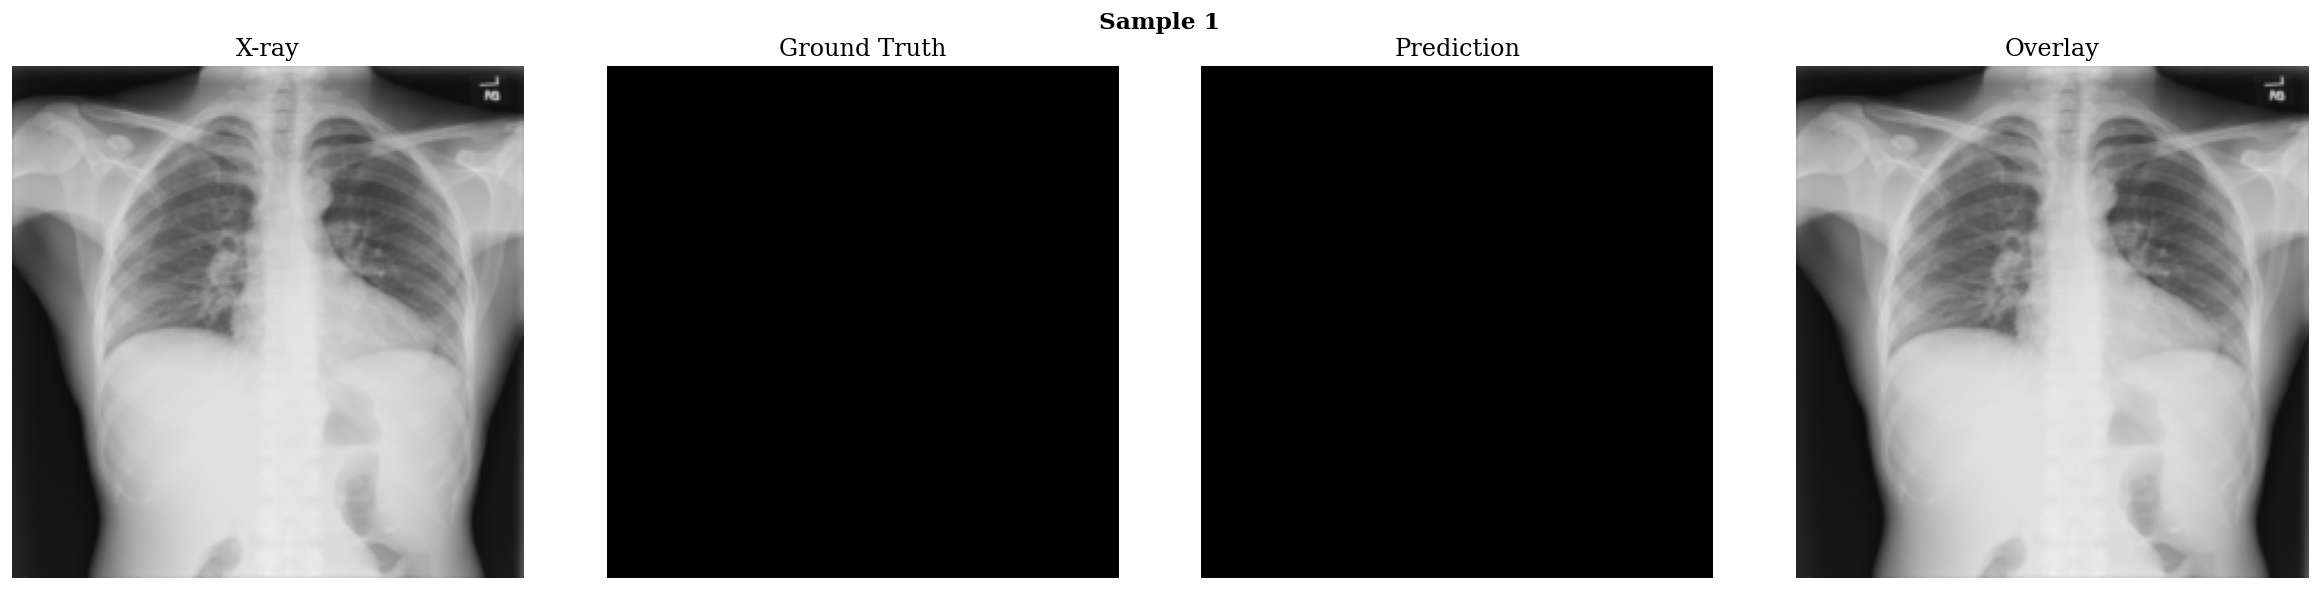

--- sample_002.png ---


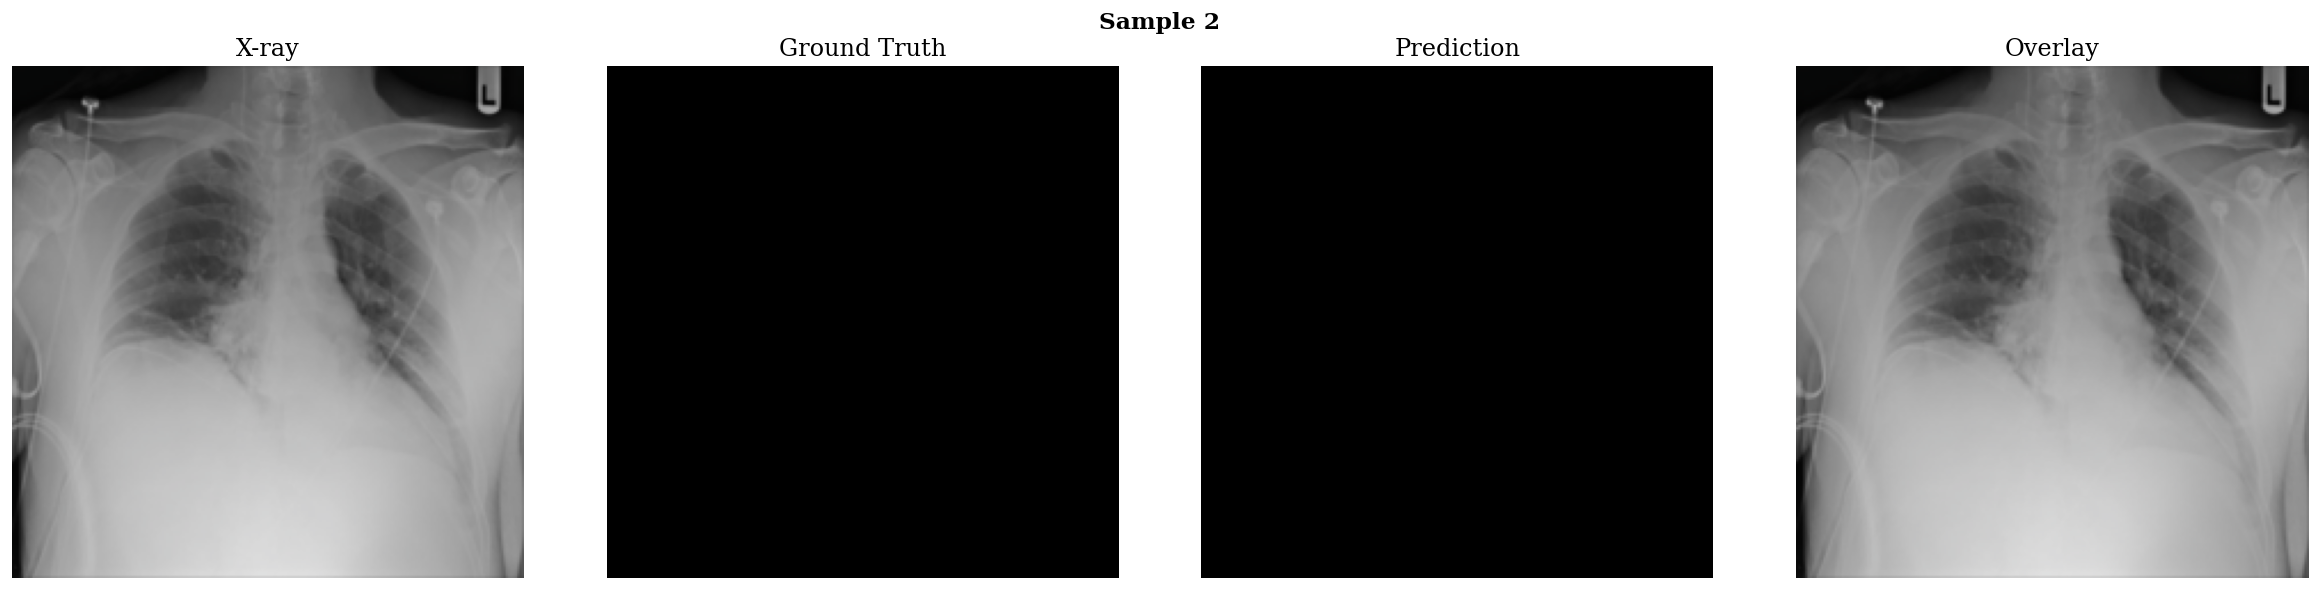

--- sample_003.png ---


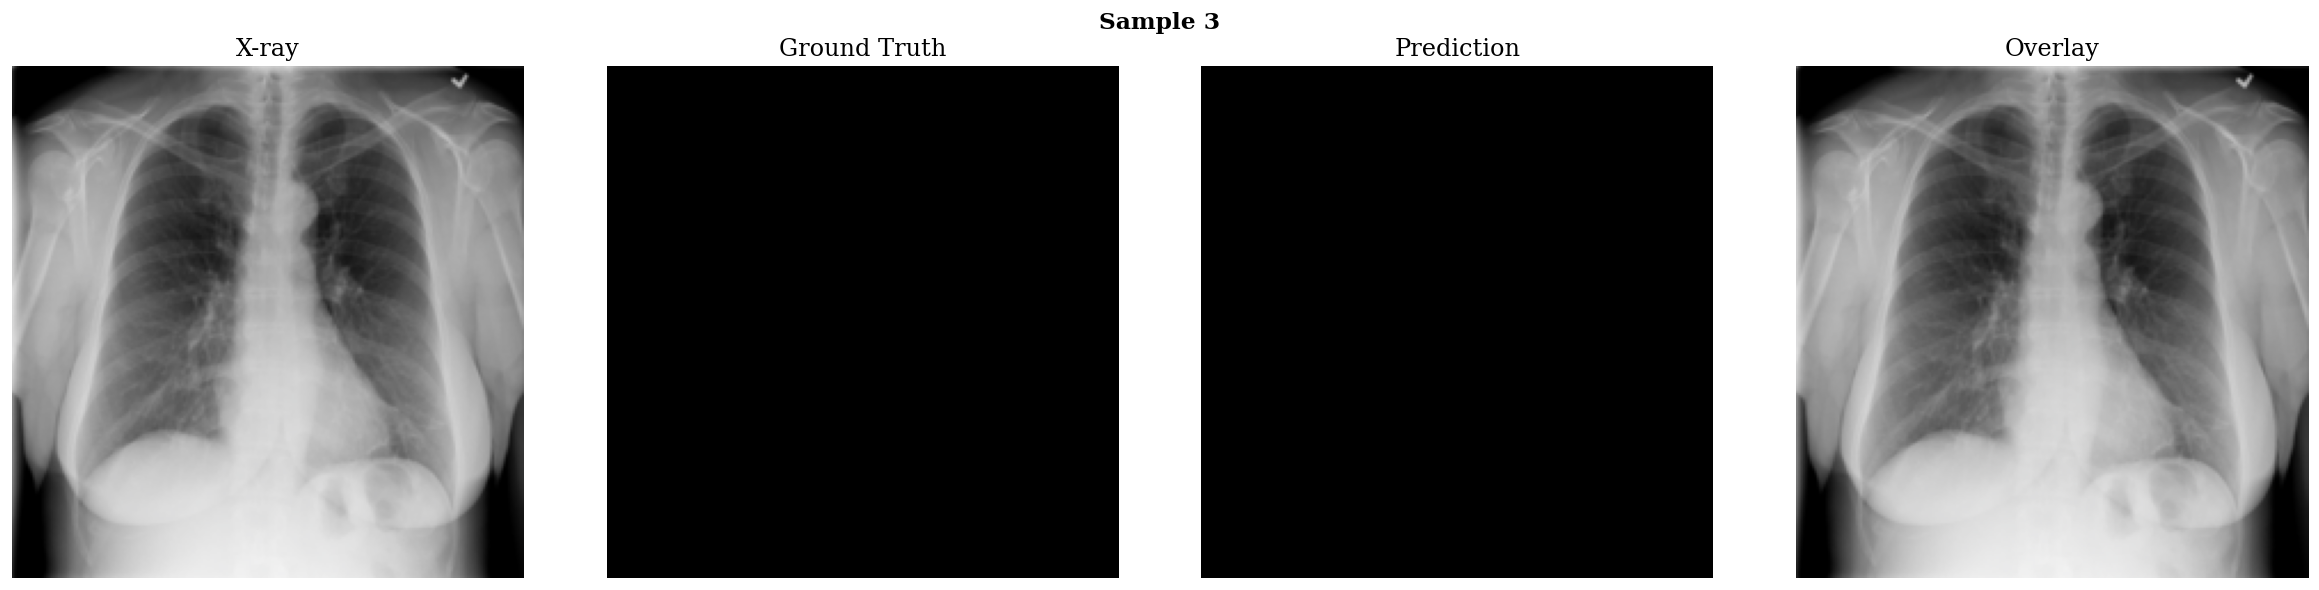

--- sample_004.png ---


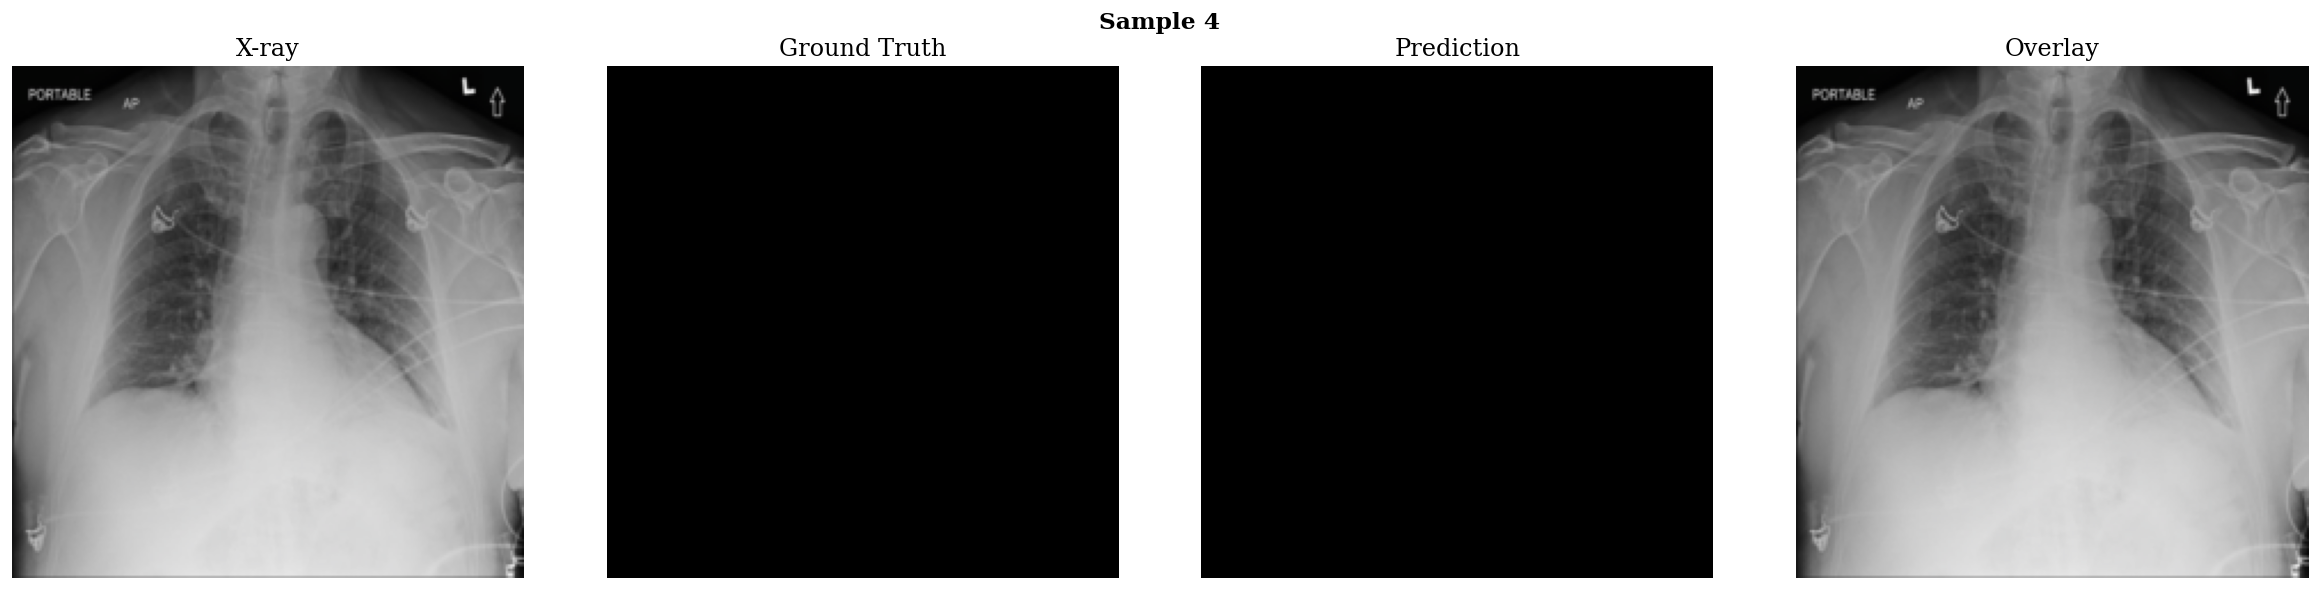

In [7]:
from IPython.display import Image as IPImage, display
import os

samples_dir = RESULTS_DIR / 'prediction_samples'
sample_files = sorted(samples_dir.glob('sample_*.png'))[:4]

print(f'Showing {len(sample_files)} prediction samples:')
print('Columns: [Original X-ray | Ground Truth Mask | Model Prediction | Overlay]\n')

for f in sample_files:
    print(f'--- {f.name} ---')
    display(IPImage(filename=str(f), width=900))

## 🎉 Training Complete!
All results are in `results/segmentation/`. Open **Notebook 09** for the full PhD-level evaluation.